# 01 SP - EDA: Censo 2022 (SP)

Exploração do arquivo `35_SP.parquet` do Censo 2022.

SP é usada como comparativo por ter maior diversidade de setores (metrópole, interior, zona rural).

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

con = duckdb.connect()
CENSO_SP = "'../data/censo 2022/35_SP.parquet'"

In [2]:
# Schema
con.execute(f"DESCRIBE SELECT * FROM read_parquet({CENSO_SP}) LIMIT 1").df()

,column_name,column_type,null,key,default,extra
0,COD_UNICO_ENDERECO,BIGINT,YES,None,None,None
1,COD_UF,BIGINT,YES,None,None,None
2,COD_MUNICIPIO,BIGINT,YES,None,None,None
3,COD_DISTRITO,BIGINT,YES,None,None,None
4,COD_SUBDISTRITO,BIGINT,YES,None,None,None
5,COD_SETOR,VARCHAR,YES,None,None,None
6,NUM_QUADRA,BIGINT,YES,None,None,None
7,NUM_FACE,BIGINT,YES,None,None,None
8,CEP,VARCHAR,YES,None,None,None
9,DSC_LOCALIDADE,VARCHAR,YES,None,None,None


In [3]:
con.execute(f"SELECT COUNT(*) as total FROM read_parquet({CENSO_SP})").df()

,total
0,22953725


In [4]:
con.execute(f"SELECT * FROM read_parquet({CENSO_SP}) LIMIT 10").df()

,COD_UNICO_ENDERECO,COD_UF,COD_MUNICIPIO,COD_DISTRITO,COD_SUBDISTRITO,COD_SETOR,NUM_QUADRA,NUM_FACE,CEP,DSC_LOCALIDADE,...,VAL_COMP_ELEM5,LATITUDE,LONGITUDE,NV_GEO_COORD,COD_ESPECIE,DSC_ESTABELECIMENTO,COD_INDICADOR_ESTAB_ENDERECO,COD_INDICADOR_CONST_ENDERECO,COD_INDICADOR_FINALIDADE_CONST,COD_TIPO_ESPECI
0,208432758,35,3528502,352850215,35285021500,352850215000063P,5,6,07661410,CENTRO,...,None,-23.268618,-46.586949,1,7,None,<NA>,1,1,<NA>
1,208432760,35,3528502,352850215,35285021500,352850215000063P,5,6,07661410,CENTRO,...,None,-23.268527,-46.587026,1,1,None,<NA>,<NA>,<NA>,101
2,208432763,35,3528502,352850215,35285021500,352850215000063P,5,6,07661410,CENTRO,...,None,-23.267537,-46.586968,1,1,None,<NA>,<NA>,<NA>,101
3,93601316,35,3527207,352720705,35272070500,352720705000248P,7,13,12602810,CAMPINHO,...,None,-22.690205,-45.105361,1,1,None,<NA>,<NA>,<NA>,101
4,54157513,35,3534401,353440105,35344010500,353440105001600P,2,4,06140030,CONCEICAO,...,None,-23.575329,-46.801904,1,1,None,<NA>,<NA>,<NA>,101
5,54086362,35,3529005,352900505,35290050500,352900505000309P,9,4,17512350,JARDIM SANTA ANTONIETA,...,None,-22.156196,-49.963527,1,1,None,<NA>,<NA>,<NA>,101
6,54086370,35,3529005,352900505,35290050500,352900505000309P,9,4,17512350,JARDIM SANTA ANTONIETA,...,None,-22.155572,-49.963139,1,1,None,<NA>,<NA>,<NA>,101
7,54086374,35,3529005,352900505,35290050500,352900505000309P,9,4,17512350,JARDIM SANTA ANTONIETA,...,None,-22.155178,-49.962918,1,1,None,<NA>,<NA>,<NA>,101
8,208506028,35,3529401,352940105,35294010500,352940105000518P,3,23,09390308,JARDIM CERQUEIRA LEITE,...,None,-23.662781,-46.453488,1,1,None,<NA>,<NA>,<NA>,101
9,54769474,35,3534708,353470805,35347080500,353470805000369P,15,6,19910270,JARDIM BRILHANTE,...,None,-22.961980,-49.897467,1,1,None,<NA>,<NA>,<NA>,101


In [5]:
# Nulos nas colunas principais
con.execute(f"""
    SELECT
        COUNT(*) FILTER (WHERE LATITUDE IS NULL)            AS lat_nulos,
        COUNT(*) FILTER (WHERE LONGITUDE IS NULL)           AS lon_nulos,
        COUNT(*) FILTER (WHERE CEP IS NULL)                 AS cep_nulos,
        COUNT(*) FILTER (WHERE COD_SETOR IS NULL)           AS setor_nulos,
        COUNT(*) FILTER (WHERE COD_ESPECIE IS NULL)         AS especie_nulos,
        COUNT(*) FILTER (WHERE DSC_ESTABELECIMENTO IS NULL) AS estab_nulos
    FROM read_parquet({CENSO_SP})
""").df()

,lat_nulos,lon_nulos,cep_nulos,setor_nulos,especie_nulos,estab_nulos
0,0,0,0,0,0,20318234


   COD_ESPECIE     total    pct
0            1  19623160  85.49
1            6   2325890  10.13
2            7    605209   2.64
3            3    199473   0.87
4            8     83938   0.37
5            5     56993   0.25
6            4     40746   0.18
7            2     18316   0.08


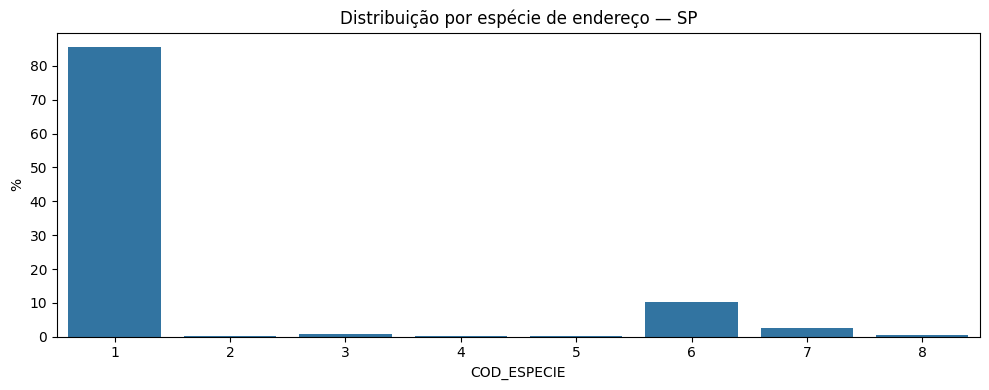

In [6]:
# Distribuição por COD_ESPECIE — comparar com BA
df_esp = con.execute(f"""
    SELECT COD_ESPECIE, COUNT(*) as total,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct
    FROM read_parquet({CENSO_SP})
    GROUP BY COD_ESPECIE ORDER BY total DESC
""").df()

print(df_esp)

plt.figure(figsize=(10, 4))
sns.barplot(data=df_esp, x='COD_ESPECIE', y='pct')
plt.title('Distribuição por espécie de endereço — SP')
plt.xlabel('COD_ESPECIE')
plt.ylabel('%')
plt.tight_layout()
plt.savefig('../outputs/figures/sp_especie_dist.png', dpi=150)
plt.show()

In [7]:
# Cobertura de coordenadas por nível de geocodificação
con.execute(f"""
    SELECT NV_GEO_COORD, COUNT(*) as total,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct
    FROM read_parquet({CENSO_SP})
    GROUP BY NV_GEO_COORD ORDER BY total DESC
""").df()

,NV_GEO_COORD,total,pct
0,1,20317716,88.52
1,2,2272608,9.90
2,3,253221,1.10
3,4,107395,0.47
4,6,2098,0.01
5,5,687,0.00


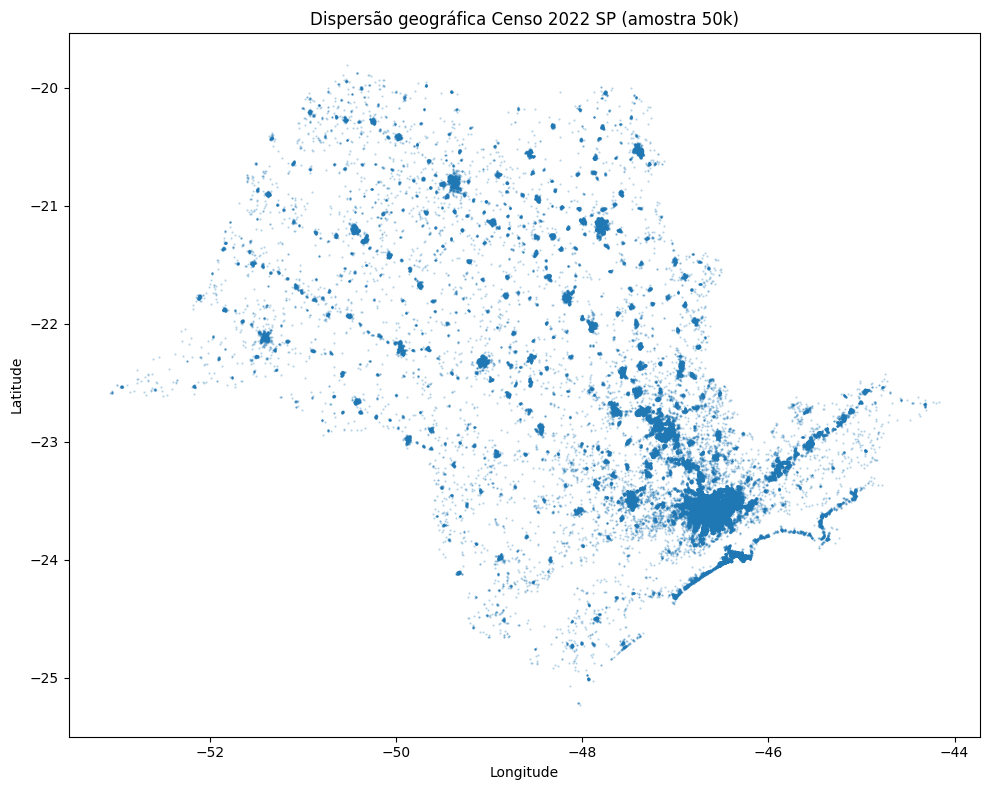

In [9]:
# Dispersão geográfica — amostra de 50k pontos
df_sample = con.execute(f"""
    SELECT LATITUDE, LONGITUDE, COD_ESPECIE
    FROM read_parquet({CENSO_SP})
    WHERE LATITUDE IS NOT NULL AND LONGITUDE IS NOT NULL
    USING SAMPLE 100000
""").df()

plt.figure(figsize=(10, 8))
plt.scatter(df_sample['LONGITUDE'], df_sample['LATITUDE'], s=0.3, alpha=0.3)
plt.title('Dispersão geográfica Censo 2022 SP (amostra 50k)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.savefig('../outputs/figures/sp_dispersao_geo.png', dpi=150)
plt.show()